# 03 — Exploration de la couche Gold : Stress Index Géopolitique × WTI

Lecture du fichier `combined/stress_index/` depuis S3 (LocalStack) pour explorer la table produite par `compute_stress_index.py`.

**Colonnes attendues :**
- **WTI** : Datetime, Open, High, Low, Close, Volume, Volatility_Range, Variation_Pct
- **GDELT lissé** : geo_I_smoothed, geo_B_smoothed, geo_S_smoothed, geo_score_raw_smoothed
- **GDELT brut** : geo_I_sum, geo_B_sum, geo_S_sum, geo_score_raw_sum
- **Métadonnées** : total_event_count, gap_duration_15m, period_actor_country
- **Percentile** : score_pct_7d

> ⚠️ Le Gold est **explosé** : une ligne par pays acteur (`period_actor_country`).  
> `df_gold["Datetime"].nunique()` donne le vrai nombre de bougies 15 min.

In [23]:
import io
import os
import boto3
import pandas as pd
import numpy as np

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Chargement du parquet Gold (dossier Spark) ──
prefix_gold = "combined/stress_index/"
objs_gold = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gold)
parquet_keys = [o["Key"] for o in objs_gold.get("Contents", []) if o["Key"].endswith(".parquet")]

dfs = []
for key in parquet_keys:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gold = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
df_gold = df_gold.sort_values("Datetime").reset_index(drop=True)

print(f"Shape : {df_gold.shape[0]} lignes × {df_gold.shape[1]} colonnes")
print(f"\nColonnes : {list(df_gold.columns)}")
print(f"\nTypes :\n{df_gold.dtypes}")
print(f"\nPlage temporelle : {df_gold['Datetime'].min()} → {df_gold['Datetime'].max()}")
df_gold.tail()

Shape : 5389 lignes × 21 colonnes

Colonnes : ['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'Volatility_Range', 'Variation_Pct', 'geo_I_smoothed', 'geo_B_smoothed', 'geo_S_smoothed', 'geo_score_raw_smoothed', 'geo_I_sum', 'geo_B_sum', 'geo_S_sum', 'geo_score_raw_sum', 'geo_score_raw_max', 'total_event_count', 'gap_duration_15m', 'score_pct_7d', 'period_actor_country']

Types :
Datetime                  datetime64[ns]
Open                             float64
High                             float64
Low                              float64
Close                            float64
Volume                             int64
Volatility_Range                 float64
Variation_Pct                    float64
geo_I_smoothed                   float64
geo_B_smoothed                   float64
geo_S_smoothed                   float64
geo_score_raw_smoothed           float64
geo_I_sum                        float64
geo_B_sum                        float64
geo_S_sum                        floa

,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,...,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,geo_score_raw_max,total_event_count,gap_duration_15m,score_pct_7d,period_actor_country
5384,2026-03-03 04:15:00,72.470001,72.669998,72.389999,72.589996,1244,0.28,0.1518,669.5,345.629411,...,16857.577716,669.5,345.629411,356.837508,16857.577716,16857.577716,172.0,1,20.35,IRN
5385,2026-03-03 04:15:00,72.470001,72.669998,72.389999,72.589996,1244,0.28,0.1518,669.5,345.629411,...,16857.577716,669.5,345.629411,356.837508,16857.577716,16857.577716,172.0,1,20.35,AUS
5386,2026-03-03 04:30:00,72.589996,72.720001,72.489998,72.620003,1073,0.23,0.0413,447.0,260.472410,...,8930.035096,447.0,260.472410,242.123197,8930.035096,8930.035096,128.0,1,9.36,PSE
5387,2026-03-03 04:30:00,72.589996,72.720001,72.489998,72.620003,1073,0.23,0.0413,447.0,260.472410,...,8930.035096,447.0,260.472410,242.123197,8930.035096,8930.035096,128.0,1,9.36,SAU
5388,2026-03-03 04:45:00,72.629997,72.790001,72.570000,72.669998,1205,0.22,0.0688,827.5,359.997727,...,21216.768574,827.5,359.997727,357.860470,21216.768574,21216.768574,178.0,1,26.39,IRN


In [ ]:
# ═══════════════════════════════════════════════
# Statistiques descriptives
# ═══════════════════════════════════════════════
n_rows = len(df_gold)
n_bougies = df_gold["Datetime"].nunique()
print(f"Lignes totales (après explode) : {n_rows:,}")
print(f"Bougies 15 min uniques         : {n_bougies:,}")
print(f"Moyenne pays acteurs / bougie  : {n_rows / n_bougies:.2f}")
print(f"\nValeurs manquantes :")
print(df_gold.isnull().sum())
print(f"\n⚠️  Doublons sur Datetime : {df_gold.duplicated(subset=['Datetime']).sum()} (normal — dû à l'explode par pays)")
print(f"\nStatistiques numériques :")
df_gold.describe().round(4)

Valeurs manquantes :
Datetime                  0
Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
Volatility_Range          0
Variation_Pct             2
geo_I_smoothed            0
geo_B_smoothed            0
geo_S_smoothed            0
geo_score_raw_smoothed    0
geo_I_sum                 0
geo_B_sum                 0
geo_S_sum                 0
geo_score_raw_sum         0
geo_score_raw_max         0
total_event_count         0
gap_duration_15m          0
score_pct_7d              0
period_actor_country      0
dtype: int64

Doublons sur Datetime : 1857

Statistiques numériques :


,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,...,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,geo_score_raw_max,total_event_count,gap_duration_15m,score_pct_7d,period_actor_country
5384,2026-03-03 04:15:00,72.470001,72.669998,72.389999,72.589996,1244,0.28,0.1518,669.5,345.629411,...,16857.577716,669.5,345.629411,356.837508,16857.577716,16857.577716,172.0,1,20.35,IRN
5385,2026-03-03 04:15:00,72.470001,72.669998,72.389999,72.589996,1244,0.28,0.1518,669.5,345.629411,...,16857.577716,669.5,345.629411,356.837508,16857.577716,16857.577716,172.0,1,20.35,AUS
5386,2026-03-03 04:30:00,72.589996,72.720001,72.489998,72.620003,1073,0.23,0.0413,447.0,260.472410,...,8930.035096,447.0,260.472410,242.123197,8930.035096,8930.035096,128.0,1,9.36,PSE
5387,2026-03-03 04:30:00,72.589996,72.720001,72.489998,72.620003,1073,0.23,0.0413,447.0,260.472410,...,8930.035096,447.0,260.472410,242.123197,8930.035096,8930.035096,128.0,1,9.36,SAU
5388,2026-03-03 04:45:00,72.629997,72.790001,72.570000,72.669998,1205,0.22,0.0688,827.5,359.997727,...,21216.768574,827.5,359.997727,357.860470,21216.768574,21216.768574,178.0,1,26.39,IRN


In [25]:
df_gold.describe().round(4)

,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,geo_S_smoothed,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,geo_score_raw_max,total_event_count,gap_duration_15m,score_pct_7d
count,5389,5389.0000,5389.0000,5389.0000,5389.0000,5389.0000,5389.0000,5387.0000,5389.0000,5389.0000,5389.0000,5389.0000,5389.0000,5389.0000,5389.0000,5.389000e+03,5389.0000,5389.0000,5389.0000,5389.0000
mean,2026-02-02 05:48:24.249396992,62.6437,62.7460,62.5367,62.6462,3866.6571,0.2093,0.0050,523.2879,304.7308,280.8524,9627.7235,718.7414,414.7002,384.4521,1.346194e+04,9666.8958,205.1301,1.5394,25.6896
min,2026-01-04 23:00:00,55.8700,55.9700,55.7600,55.8700,25.0000,0.0200,-3.7394,114.0000,82.2357,73.7258,1367.5874,114.0000,82.2357,73.7258,1.367587e+03,1367.5874,41.0000,1.0000,0.0000
25%,2026-01-20 05:45:00,59.9900,60.0500,59.8700,59.9700,737.0000,0.1100,-0.0980,393.0000,245.2012,224.8679,6734.3454,393.0000,245.2012,224.8679,6.734345e+03,6734.3454,121.0000,1.0000,16.5200
50%,2026-02-03 01:45:00,62.8600,62.9400,62.7800,62.8700,2090.0000,0.1600,0.0150,501.5000,295.5819,272.1186,8899.0532,501.5000,295.5819,272.1186,8.899053e+03,8899.0532,147.0000,1.0000,23.7400
75%,2026-02-17 18:30:00,64.9900,65.0800,64.8700,64.9900,5083.0000,0.2500,0.1171,615.5000,351.1864,324.3895,11498.3388,615.5000,351.1864,324.3895,1.149834e+04,11498.3388,174.0000,1.0000,32.3000
max,2026-03-03 04:45:00,73.2300,73.3700,72.8200,73.2400,260246.0000,2.5900,7.7872,2050.4756,895.4728,829.3318,74319.2955,115122.5000,51732.8431,51683.1908,3.131135e+06,88925.5976,25438.0000,220.0000,100.0000
std,NaN,3.3537,3.3783,3.3262,3.3558,6958.7645,0.1684,0.2812,189.3334,89.0632,83.5898,4509.9272,3350.4164,1856.8193,1757.0742,7.036564e+04,4709.1523,916.8960,9.4377,13.6941


In [26]:
df_gold.iloc[df_gold['Variation_Pct'].idxmax()]

Datetime                  2026-03-01 23:00:00
Open                                71.860001
High                                72.550003
Low                                 71.040001
Close                               72.529999
Volume                                   9092
Volatility_Range                         1.51
Variation_Pct                          7.7872
geo_I_smoothed                    2050.475635
geo_B_smoothed                     842.033505
geo_S_smoothed                     808.373639
geo_score_raw_smoothed           74319.295478
geo_I_sum                            115122.5
geo_B_sum                        51732.843096
geo_S_sum                        51683.190791
geo_score_raw_sum              3131135.163232
geo_score_raw_max                88925.597567
total_event_count                     25438.0
gap_duration_15m                          197
score_pct_7d                            100.0
period_actor_country                      IRN
Name: 5195, dtype: object

---
## Visualisations

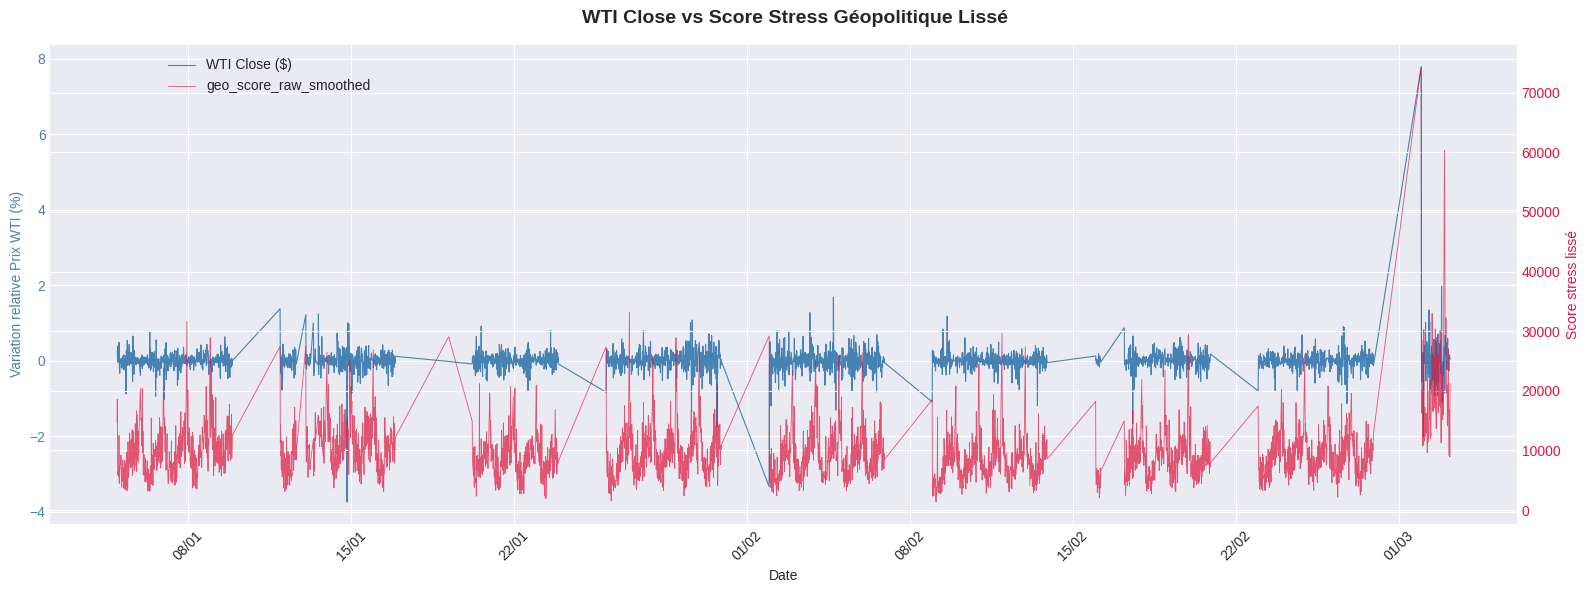

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")

# ═══════════════════════════════════════════════
# 1. Prix WTI (Close) + Score Stress lissé (double axe)
# ═══════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(df_gold["Datetime"], df_gold["Variation_Pct"], color="steelblue", linewidth=0.8, label="WTI Close ($)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Variation relative Prix WTI (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_gold["Datetime"], df_gold["geo_score_raw_smoothed"], color="crimson", linewidth=0.6, alpha=0.7, label="geo_score_raw_smoothed")
ax2.set_ylabel("Score stress lissé", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

fig.suptitle("WTI Close vs Score Stress Géopolitique Lissé", fontweight="bold", fontsize=14)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.92))
plt.tight_layout()
plt.show()

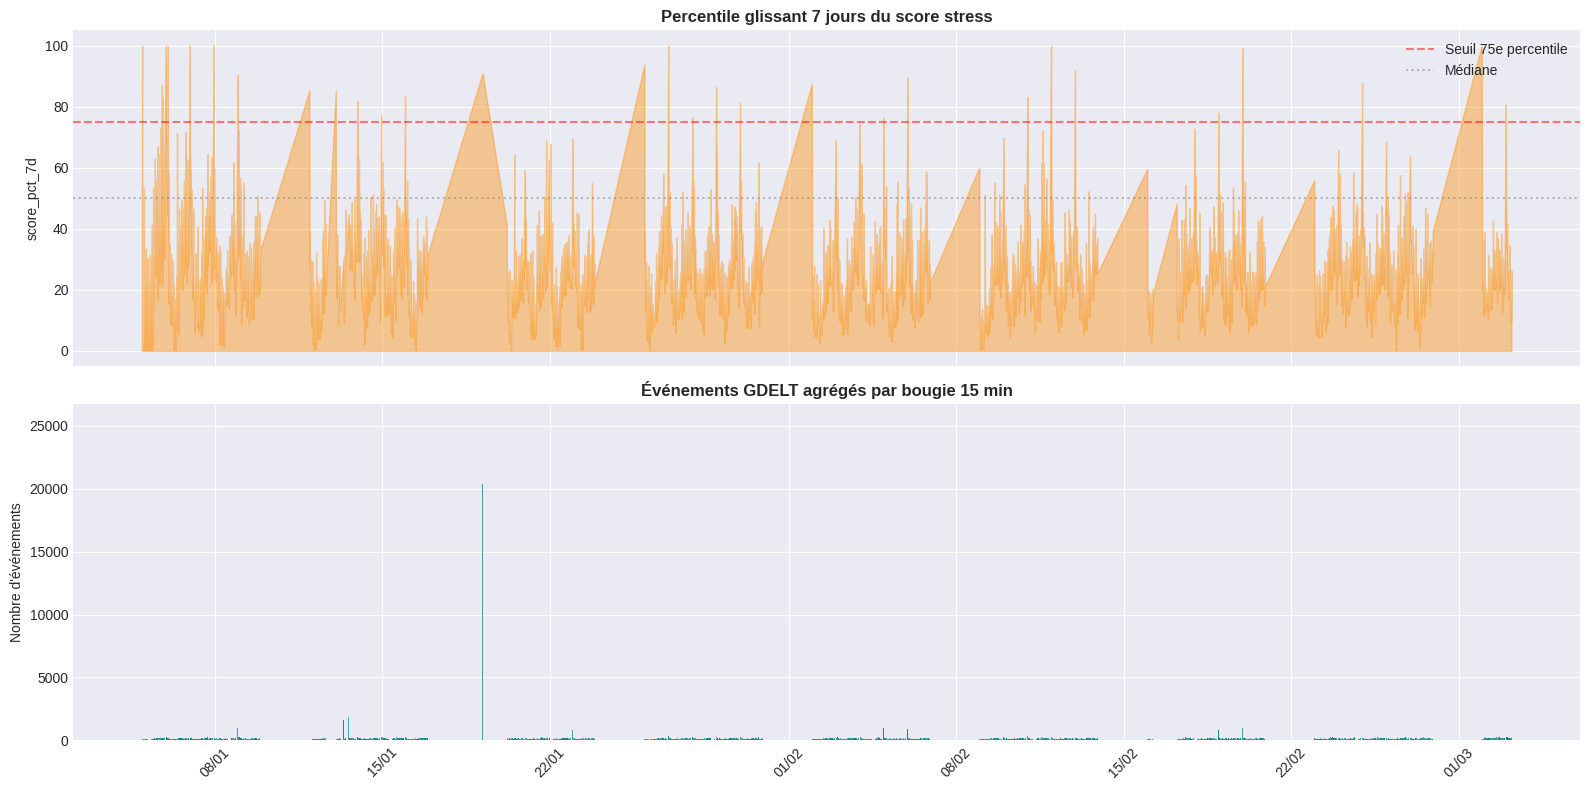

In [28]:
# ═══════════════════════════════════════════════
# 2. Percentile 7 jours (score_pct_7d) + Nombre d'événements
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Percentile 7j
axes[0].fill_between(df_gold["Datetime"], df_gold["score_pct_7d"], alpha=0.4, color="darkorange")
axes[0].axhline(y=75, color="red", linestyle="--", alpha=0.5, label="Seuil 75e percentile")
axes[0].axhline(y=50, color="gray", linestyle=":", alpha=0.5, label="Médiane")
axes[0].set_ylabel("score_pct_7d")
axes[0].set_title("Percentile glissant 7 jours du score stress", fontweight="bold")
axes[0].legend()

# Nombre d'événements
axes[1].bar(df_gold["Datetime"], df_gold["total_event_count"], color="teal", alpha=0.7, width=0.01)
axes[1].set_ylabel("Nombre d'événements")
axes[1].set_title("Événements GDELT agrégés par bougie 15 min", fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

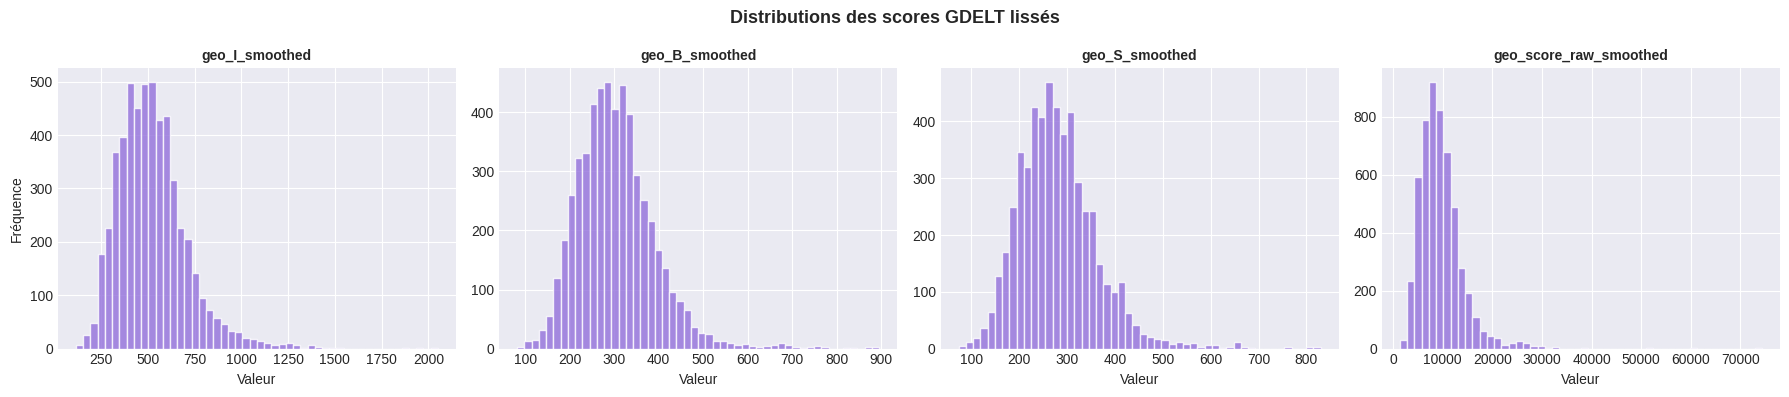

In [29]:
# ═══════════════════════════════════════════════
# 3. Distributions des scores lissés
# ═══════════════════════════════════════════════
score_cols_smoothed = ["geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(score_cols_smoothed):
    axes[i].hist(df_gold[col].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence" if i == 0 else "")

plt.suptitle("Distributions des scores GDELT lissés", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

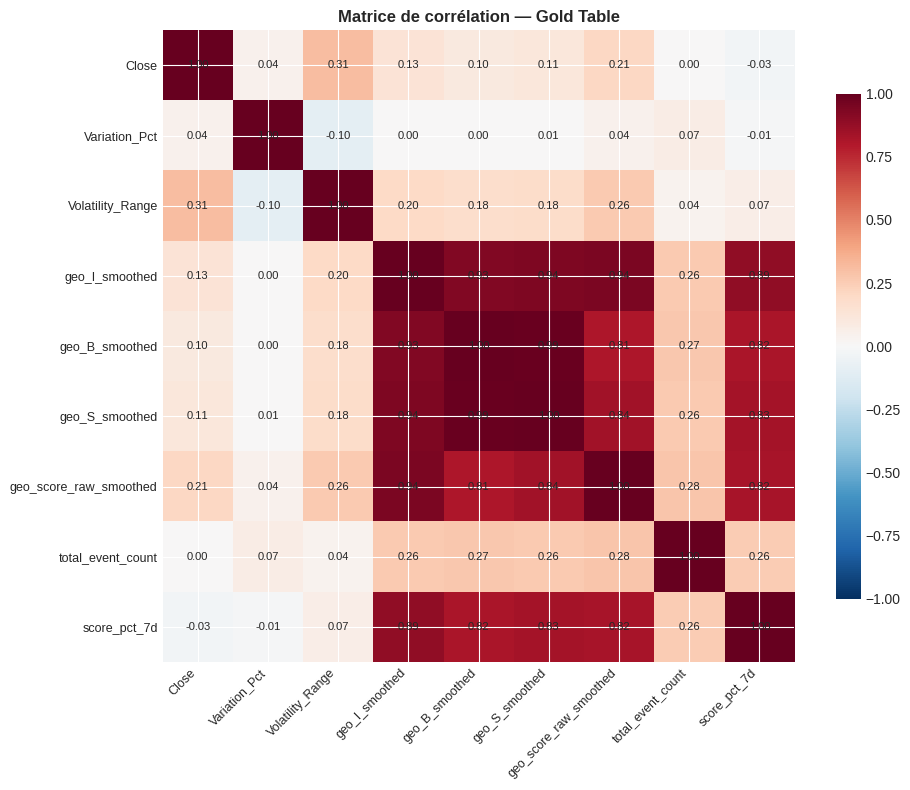

In [30]:
# ═══════════════════════════════════════════════
# 4. Matrice de corrélation
# ═══════════════════════════════════════════════
corr_cols = [
    "Close", "Variation_Pct", "Volatility_Range",
    "geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed",
    "total_event_count", "score_pct_7d",
]
corr_matrix = df_gold[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotations
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.title("Matrice de corrélation — Gold Table", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════
# 5. Top acteurs géopolitiques (period_actor_country)
# ═══════════════════════════════════════════════
top_actors = df_gold["period_actor_country"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_actors.plot(kind="barh", color="coral", alpha=0.85, edgecolor="white", ax=ax)
ax.set_title("Top 15 pays acteurs géopolitiques (period_actor_country)", fontweight="bold")
ax.set_xlabel("Nombre de lignes Gold (1 ligne = 1 bougie × 1 pays)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

KeyError: 'period_main_actor'

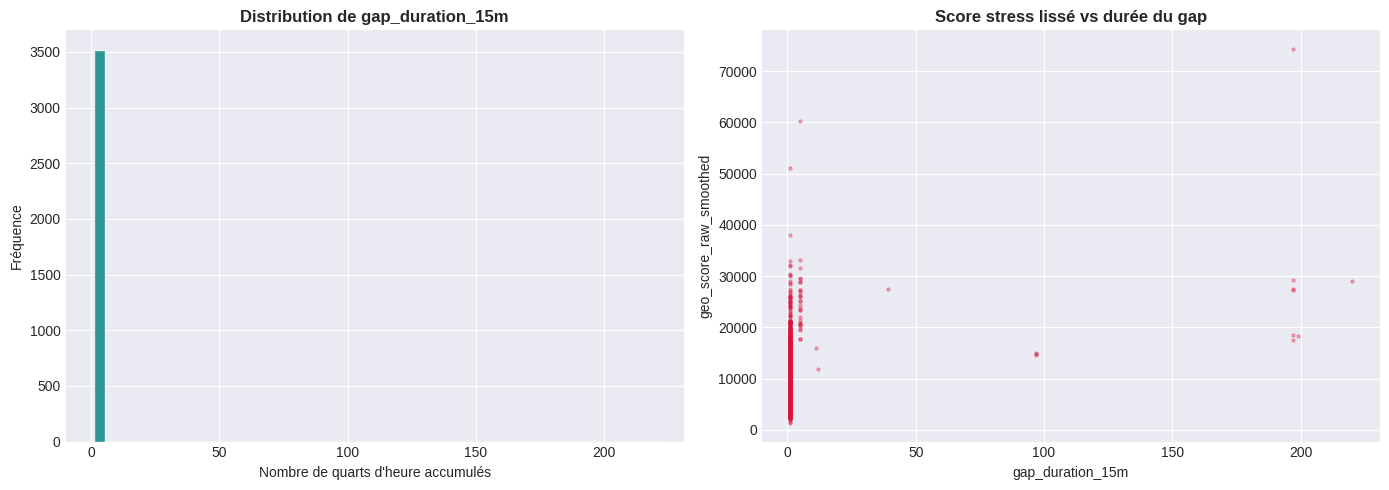

In [ ]:
# ═══════════════════════════════════════════════
# 6. Gap duration : analyse du forward mapping
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de gap_duration_15m
axes[0].hist(df_gold["gap_duration_15m"].dropna(), bins=50, color="teal", alpha=0.8, edgecolor="white")
axes[0].set_title("Distribution de gap_duration_15m", fontweight="bold")
axes[0].set_xlabel("Nombre de quarts d'heure accumulés")
axes[0].set_ylabel("Fréquence")

# Score stress vs gap_duration (les réouvertures après longs gaps sont-elles plus stressées ?)
axes[1].scatter(df_gold["gap_duration_15m"], df_gold["geo_score_raw_smoothed"],
               alpha=0.3, s=5, color="crimson")
axes[1].set_title("Score stress lissé vs durée du gap", fontweight="bold")
axes[1].set_xlabel("gap_duration_15m")
axes[1].set_ylabel("geo_score_raw_smoothed")

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════
# 7. Aperçu des lignes avec le score stress le plus élevé
# ═══════════════════════════════════════════════
top_stress = (
    df_gold
    .drop_duplicates(subset=["Datetime"])   # déduplique pour ne pas répéter la même bougie
    .nlargest(20, "geo_score_raw_smoothed")
    [["Datetime", "Close", "Variation_Pct", "geo_score_raw_smoothed",
      "score_pct_7d", "total_event_count", "period_actor_country", "gap_duration_15m"]]
)
print("Top 20 bougies avec le score stress lissé le plus élevé :")
top_stress

Top 20 bougies avec le score stress lissé le plus élevé :


,Datetime,Close,Variation_Pct,geo_score_raw_smoothed,score_pct_7d,total_event_count,period_main_actor,gap_duration_15m
3416,2026-03-01 23:00:00,72.529999,7.7872,74319.295478,100.00,25438.0,IRN,197
3508,2026-03-02 23:00:00,71.300003,0.3801,60335.516225,80.62,1152.0,IRN,5
3509,2026-03-02 23:15:00,70.690002,-0.8555,51111.146465,67.83,376.0,IRN,1
3510,2026-03-02 23:30:00,70.419998,-0.3820,38088.022017,49.78,311.0,IRN,1
1302,2026-01-26 23:00:00,60.860001,0.0493,33175.013066,100.00,984.0,IRQ,5
3461,2026-03-02 10:15:00,72.029999,0.0000,33001.245843,42.73,270.0,IRN,1
3514,2026-03-03 00:30:00,71.410004,0.1824,32231.273399,41.66,242.0,IRN,1
3417,2026-03-01 23:15:00,72.529999,0.0000,31941.077285,41.26,205.0,IRN,1
276,2026-01-07 23:00:00,56.330002,-0.1241,31644.363484,100.00,932.0,RUS,5
3474,2026-03-02 13:30:00,72.330002,0.0138,30372.196677,39.08,232.0,IRN,1


In [ ]:
# Diagnostic GDELT
print("=== Scores GDELT lissés ===")
for col in ["geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed"]:
    print(f"{col}: min={df_gold[col].min():.4f}, max={df_gold[col].max():.4f}, mean={df_gold[col].mean():.4f}, non-zero={(df_gold[col] != 0).sum()}/{len(df_gold)}")

print(f"\n=== period_actor_country ===")
print(df_gold["period_actor_country"].value_counts())

print(f"\n=== total_event_count ===")
print(f"min={df_gold['total_event_count'].min()}, max={df_gold['total_event_count'].max()}, mean={df_gold['total_event_count'].mean():.2f}")
print(f"Bougies avec 0 événements : {(df_gold['total_event_count'] == 0).sum()}/{len(df_gold)}")

print(f"\n=== score_pct_7d ===")
print(df_gold["score_pct_7d"].describe())

=== Scores GDELT lissés ===
geo_I_smoothed: min=114.0000, max=2050.4756, mean=522.7820, non-zero=3532/3532
geo_B_smoothed: min=82.2357, max=895.4728, mean=304.9109, non-zero=3532/3532
geo_S_smoothed: min=73.7258, max=829.3318, mean=280.8986, non-zero=3532/3532
geo_score_raw_smoothed: min=1367.5874, max=74319.2955, mean=9593.0595, non-zero=3532/3532

=== period_main_actor ===
period_main_actor
IRN    1772
RUS    1132
USA     217
IRQ     188
SAU     109
IR       56
RS       44
SA        8
IZ        5
US        1
Name: count, dtype: int64

=== total_event_count ===
min=41.0, max=25438.0, mean=209.90
Bougies avec 0 événements : 0/3532

=== score_pct_7d ===
count    3532.000000
mean       25.652055
std        13.828567
min         0.000000
25%        16.462500
50%        23.635000
75%        32.300000
max       100.000000
Name: score_pct_7d, dtype: float64
